In [1]:
# Para tratamiento de datos
import polars as pl
import math
# Para visualizaciones
import seaborn as sns 
import matplotlib.pyplot as plt
# Para gestión de fechas
from datetime import datetime
# Para conectar a la base de datos
import psycopg2
# Cargar variables de entorno
import os
from dotenv import load_dotenv
# Configuracion de Polars para mostrar todas las columnas y hasta 25 filas
pl.Config.set_tbl_rows(1000)  # Asegura que se muestren hasta 1000 filas
pl.Config.set_tbl_width_chars(500)  # Aumenta el ancho para evitar cortes
# importamos funciones de soporte
from src import funciones_load as fl
from src import funciones_eda as feda

In [2]:
conexion = os.getenv("conexion_bbdd")
madrid_24 = feda.obtener_datos_madrid(conexion, 2024, 2024, "Madrid")

Conexión establecida y consulta de prueba exitosa.


In [3]:
df_mensual, estaciones, contaminantes = feda.preproceso_datos(madrid_24)

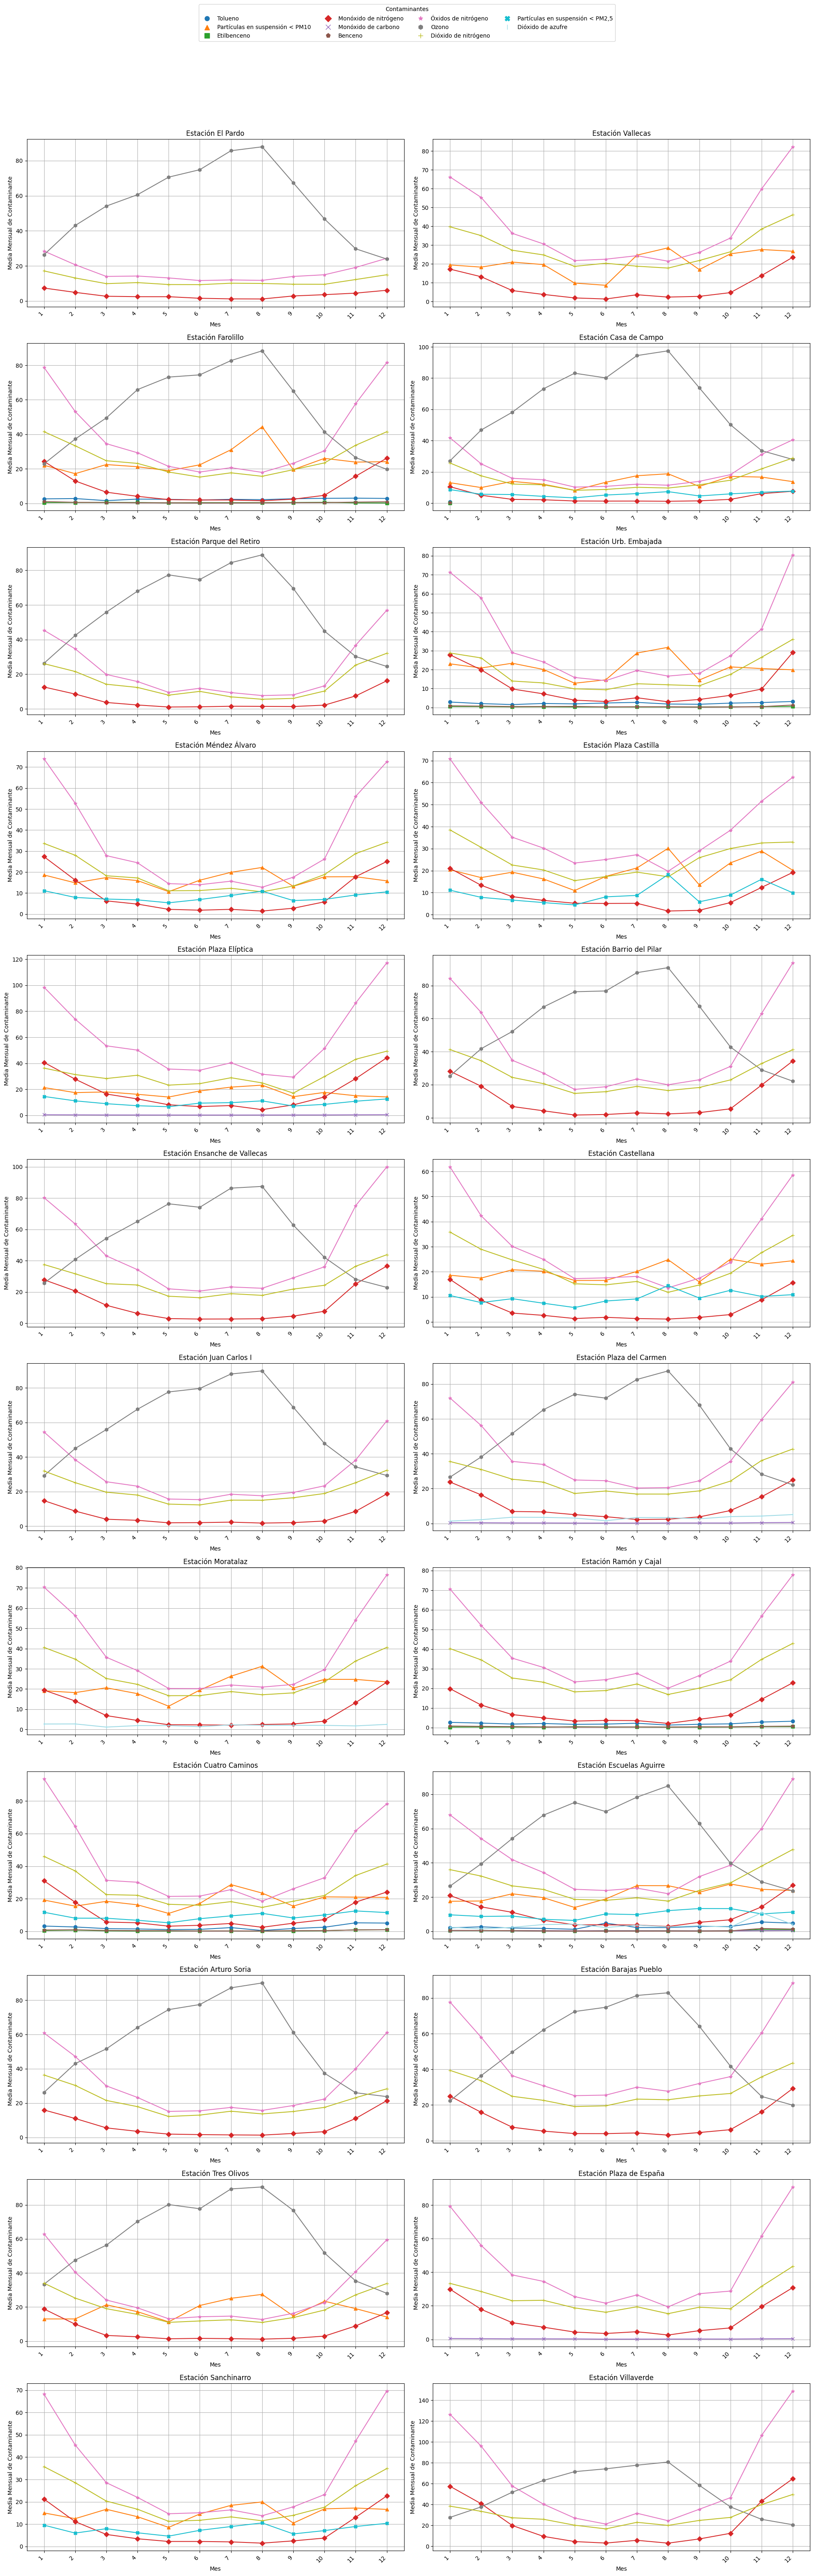

In [4]:
feda.graficos_estaciones(df_mensual, estaciones, contaminantes)

Analizamos los contaminantes que se miden en más estaciones, ya que son los que permiten mejor comparación entre ellas.

In [5]:
contaminantes_por_estacion = (
    madrid_24.group_by("contaminante")
    .agg(pl.col("estacion").n_unique().alias("num_estaciones"))
    .sort("num_estaciones", descending=True)  # Opcional, para ordenar de mayor a menor
)
contaminantes_por_estacion

contaminante,num_estaciones
str,u32
"""Óxidos de nitrógeno""",24
"""Monóxido de nitrógeno""",24
"""Dióxido de nitrógeno""",24
"""Ozono""",13
"""Partículas en suspensión < PM1…",13
"""Partículas en suspensión < PM2…",8
"""Etilbenceno""",6
"""Benceno""",6
"""Tolueno""",6


Aunque los  **Óxidos de nitrógeno** siguen un patrón similar a los anteriores años, cabe destacar que los valores mínimos se dan entre mayo y agosto, mientras que otros años se daban entre marzo y octubre. El **Ozono** mantiene su tendencia ascendente desde enero a mayo, cae ligeramente en junio y sube hasta alcanzar el máximo en julio - agosto.   
En cuanto a las **Partículas en suspensión < PM10**, siguen un patrón similar en todas las estaciones, con un ligero aumento en marzo (podría ser polen) y un máximo en agosto (polvo africano)